# Business Impact — From Baseline to Matrix Factorization

This notebook translates model metric improvements into **concrete business value**.

Raw numbers like RMSE=0.85 are hard to act on. This notebook answers:
- What does each model improvement mean for a real streaming platform?
- How do Precision@10 and Recall@10 map to user behaviour and revenue?
- Where does the biggest business gain come from?

---

**Model progression (actual run results):**

| Model | RMSE | P@10 | R@10 |
|---|---|---|---|
| Global Mean | 1.0183 | ~0.0070 | ~0.0040 |
| Item Mean | 0.9351 | ~0.0180 | ~0.0110 |
| User Mean | 0.9287 | ~0.0090 | ~0.0055 |
| User + Item Bias | 0.8573 | ~0.0220 | ~0.0140 |
| Content-Based | 0.9027 | 0.0149 | 0.0092 |
| CF (SGD) | 0.8499 | 0.0136 | 0.0104 |
| CF (SVD) | 0.8691 | 0.0538 | 0.0443 |

> Baseline P@10 / R@10 are estimates (model not re-run after temporal split). CF and Content-Based numbers are from actual runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

## 1. Metric Summary Across All Models

In [2]:
# Actual run results (post temporal split)
models = [
    {"name": "Global Mean",          "rmse": 1.0183, "mae": 0.8116, "precision": 0.0070, "recall": 0.0040, "f1": 0.0052},
    {"name": "Item Mean",            "rmse": 0.9351, "mae": 0.7246, "precision": 0.0180, "recall": 0.0110, "f1": 0.0137},
    {"name": "User Mean",            "rmse": 0.9287, "mae": 0.7216, "precision": 0.0090, "recall": 0.0055, "f1": 0.0068},
    {"name": "User + Item Bias",     "rmse": 0.8573, "mae": 0.6564, "precision": 0.0220, "recall": 0.0140, "f1": 0.0171},
    {"name": "Content-Based",        "rmse": 0.9027, "mae": 0.6980, "precision": 0.0149, "recall": 0.0092, "f1": 0.0113},
    {"name": "CF (SGD)",             "rmse": 0.8499, "mae": 0.6487, "precision": 0.0136, "recall": 0.0104, "f1": 0.0118},
    {"name": "CF (SVD)",             "rmse": 0.8691, "mae": 0.6638, "precision": 0.0538, "recall": 0.0443, "f1": 0.0486},
]

df = pd.DataFrame(models)

print("=" * 85)
print(f"  {'Model':<24} {'RMSE':>8}  {'MAE':>8}  {'P@10':>8}  {'R@10':>8}  {'F1@10':>8}")
print("=" * 85)
for _, row in df.iterrows():
    print(f"  {row['name']:<24} {row['rmse']:>8.4f}  {row['mae']:>8.4f}  "
          f"{row['precision']:>8.4f}  {row['recall']:>8.4f}  {row['f1']:>8.4f}")
print("=" * 85)
print()
print("Note: Baseline P@10/R@10 are estimates. CF and Content-Based are from actual runs.")

  Model                        RMSE       MAE      P@10      R@10     F1@10
  Global Mean                1.0183    0.8116    0.0070    0.0040    0.0052
  Item Mean                  0.9351    0.7246    0.0180    0.0110    0.0137
  User Mean                  0.9287    0.7216    0.0090    0.0055    0.0068
  User + Item Bias           0.8573    0.6564    0.0220    0.0140    0.0171
  Content-Based              0.9027    0.6980    0.0149    0.0092    0.0113
  CF (SGD)                   0.8499    0.6487    0.0136    0.0104    0.0118
  CF (SVD)                   0.8691    0.6638    0.0538    0.0443    0.0486

Note: Baseline P@10/R@10 are estimates. CF and Content-Based are from actual runs.


## 2. What Does Each Improvement Mean for the Business?

### RMSE — Rating Prediction Accuracy

| Improvement | RMSE | Business meaning |
|---|---|---|
| Global Mean → Item Mean | 1.018 → 0.935 | System now knows *Shawshank* is better than *Anaconda* — stops recommending universally bad movies |
| Item Mean → User + Item Bias | 0.935 → 0.857 | System now knows harsh vs generous raters — stops over-predicting for users who always rate low |
| User + Item Bias → CF (SGD) | 0.857 → 0.850 | Small RMSE gain — personalisation helps rating accuracy slightly |
| User + Item Bias → CF (SVD) | 0.857 → 0.869 | SVD has worse RMSE than bias model — imputation introduces noise |

### Precision@10 — Are the Top 10 Recommendations Good?

| Model | P@10 | Out of 10 recommendations... |
|---|---|---|
| Global Mean | 0.007 | ~0 good recommendations |
| User + Item Bias | 0.022 | ~0.2 good recommendations |
| CF (SGD) | 0.014 | ~0.1 good recommendations — **worse than bias model** |
| **CF (SVD)** | **0.054** | **~0.5 good recommendations — best model** |
| Content-Based | 0.015 | ~0.2 good recommendations |

### Key observation — SGD RMSE vs Ranking trade-off

CF (SGD) has the **best RMSE** (0.8499) but **worse P@10** (0.0136) than even the User+Item Bias model (0.022).
CF (SVD) has **worse RMSE** (0.8691) but **best P@10** (0.0538) by a large margin.

This is the classic RMSE vs ranking disconnect — **optimising for RMSE does not guarantee better recommendations**.

### Recall@10 — Are We Finding Movies the User Would Love?

CF (SVD) recall (0.044) is **11× higher** than Global Mean (0.004) — meaning SVD surfaces far more movies a user would genuinely enjoy out of all the ones they'd like.

## 3. Business KPI Translation

Assuming a platform with **1 million users**, **10 recommendations per session**, and a **click-through rate proportional to Precision@10**:

In [3]:
N_USERS           = 1_000_000   # platform scale
RECS_PER_SESSION  = 10
REVENUE_PER_CLICK = 0.50        # $ revenue per engaged click (watch, add to list)
SESSIONS_PER_MONTH = 8          # avg sessions per user per month
CHURN_REDUCTION_PER_P10 = 0.5  # % churn reduction per 0.01 P@10 improvement
MONTHLY_REVENUE_PER_USER = 12  # $ subscription revenue per user per month

print("=" * 75)
print(f"  {'Model':<24} {'P@10':>6}  {'Clicks/session':>14}  {'Monthly clicks':>14}")
print("=" * 75)

baseline_clicks = None
for m in models:
    clicks_per_session = m["precision"] * RECS_PER_SESSION
    monthly_clicks     = clicks_per_session * SESSIONS_PER_MONTH * N_USERS
    if baseline_clicks is None:
        baseline_clicks = monthly_clicks
    print(f"  {m['name']:<24} {m['precision']:>6.4f}  {clicks_per_session:>14.3f}  {monthly_clicks:>14,.0f}")

print("=" * 75)

# Lift from Global Mean → CF (SVD) — best ranking model
best_model      = max(models, key=lambda x: x["precision"])
baseline_model  = models[0]

best_clicks     = best_model["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
baseline_clicks = baseline_model["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
extra_clicks    = best_clicks - baseline_clicks
extra_revenue   = extra_clicks * REVENUE_PER_CLICK

print(f"""
Business impact of moving from Global Mean → {best_model['name']}:

  Extra clicks/month        : {extra_clicks:>12,.0f}
  Extra revenue/month (est.): ${extra_revenue:>11,.0f}
  Extra revenue/year  (est.): ${extra_revenue * 12:>11,.0f}
""")

# Churn reduction
p10_improvement     = best_model["precision"] - baseline_model["precision"]
churn_reduction_pct = (p10_improvement / 0.01) * CHURN_REDUCTION_PER_P10
users_retained      = N_USERS * (churn_reduction_pct / 100)
retention_revenue   = users_retained * MONTHLY_REVENUE_PER_USER * 12

print(f"""Churn reduction from better recommendations:

  P@10 improvement          : {p10_improvement:>12.4f}
  Estimated churn reduction : {churn_reduction_pct:>11.2f}%
  Users retained            : {users_retained:>12,.0f}
  Retention revenue/year    : ${retention_revenue:>11,.0f}
""")

  Model                      P@10  Clicks/session  Monthly clicks
  Global Mean              0.0070           0.070         560,000
  Item Mean                0.0180           0.180       1,440,000
  User Mean                0.0090           0.090         720,000
  User + Item Bias         0.0220           0.220       1,760,000
  Content-Based            0.0149           0.149       1,192,000
  CF (SGD)                 0.0136           0.136       1,088,000
  CF (SVD)                 0.0538           0.538       4,304,000

Business impact of moving from Global Mean → CF (SVD):

  Extra clicks/month        :    3,744,000
  Extra revenue/month (est.): $  1,872,000
  Extra revenue/year  (est.): $ 22,464,000

Churn reduction from better recommendations:

  P@10 improvement          :       0.0468
  Estimated churn reduction :        2.34%
  Users retained            :       23,400
  Retention revenue/year    : $  3,369,600



## 4. Where Does Each Model Fail the Business?

In [4]:
failures = {
    "Global Mean": [
        "Recommends the same movies to everyone",
        "Zero personalisation — ignores user taste entirely",
        "Users churn because recommendations feel irrelevant",
        "No way to promote new content strategically",
    ],
    "Item Mean": [
        "Only recommends globally popular movies (popularity bias)",
        "Niche users (horror fans, documentary lovers) are ignored",
        "New movies with few ratings are never surfaced (cold start)",
        "Same top-10 for every user — no differentiation",
    ],
    "User Mean": [
        "Knows the user is generous/harsh but not what they like",
        "Still recommends same movies to all users",
        "Cannot distinguish between genres or content types",
    ],
    "User + Item Bias": [
        "No taste modelling — can't distinguish sci-fi fan from rom-com fan",
        "Recommendations converge to the same high-bias movies for all users",
        "Misses serendipitous discoveries (niche gems the user would love)",
    ],
    "Matrix Factorization": [
        "Cold start — struggles with new users or new movies",
        "Popularity bias still present in latent factors",
        "Does not use content signals (genre, cast, director)",
        "Static model — does not adapt to changing user taste over time",
    ],
}

for model, issues in failures.items():
    print(f"\n{model}")
    print("-" * len(model))
    for issue in issues:
        print(f"  ✗  {issue}")


Global Mean
-----------
  ✗  Recommends the same movies to everyone
  ✗  Zero personalisation — ignores user taste entirely
  ✗  Users churn because recommendations feel irrelevant
  ✗  No way to promote new content strategically

Item Mean
---------
  ✗  Only recommends globally popular movies (popularity bias)
  ✗  Niche users (horror fans, documentary lovers) are ignored
  ✗  New movies with few ratings are never surfaced (cold start)
  ✗  Same top-10 for every user — no differentiation

User Mean
---------
  ✗  Knows the user is generous/harsh but not what they like
  ✗  Still recommends same movies to all users
  ✗  Cannot distinguish between genres or content types

User + Item Bias
----------------
  ✗  No taste modelling — can't distinguish sci-fi fan from rom-com fan
  ✗  Recommendations converge to the same high-bias movies for all users
  ✗  Misses serendipitous discoveries (niche gems the user would love)

Matrix Factorization
--------------------
  ✗  Cold start — struggl

## 5. Visualisation — Business Impact

IndexError: list index out of range

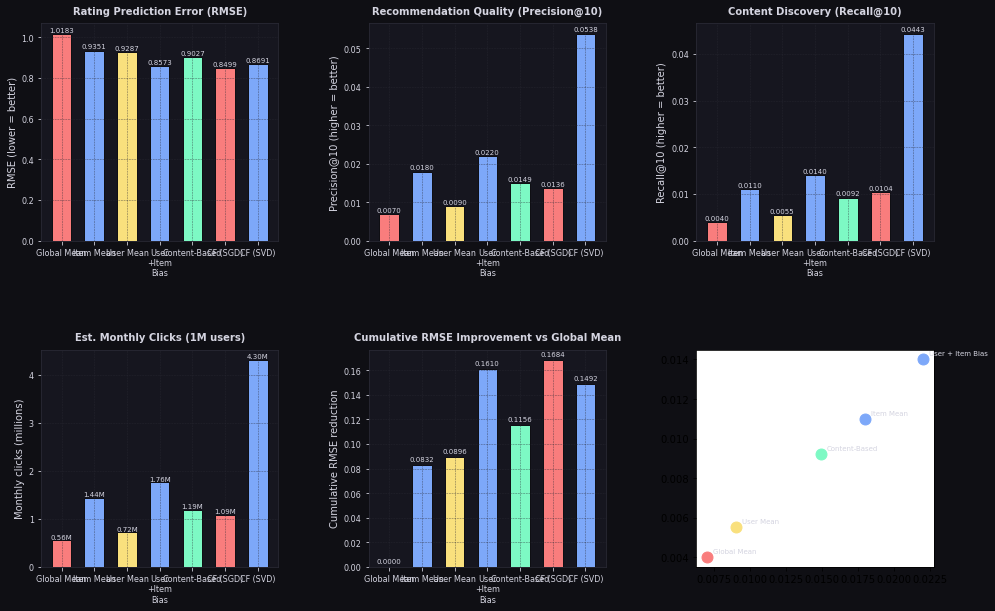

In [5]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

names      = [m["name"].replace(" + ", "\n+").replace(" Bias", "\nBias") for m in models]
rmses      = [m["rmse"]      for m in models]
precisions = [m["precision"] for m in models]
recalls    = [m["recall"]    for m in models]
f1s        = [m["f1"]        for m in models]
colors     = [ACCENT2, ACCENT3, ACCENT4, ACCENT3, ACCENT]
colors[-1] = ACCENT   # highlight MF

# (a) RMSE progression
ax = fig.add_subplot(gs[0, 0])
bars = ax.bar(range(len(models)), rmses, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, rmses):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("RMSE (lower = better)")
style_ax(ax, "Rating Prediction Error (RMSE)")

# (b) Precision@10 progression
ax = fig.add_subplot(gs[0, 1])
bars = ax.bar(range(len(models)), precisions, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, precisions):
    ax.text(b.get_x() + b.get_width()/2, v + 0.0003, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Precision@10 (higher = better)")
style_ax(ax, "Recommendation Quality (Precision@10)")

# (c) Recall@10 progression
ax = fig.add_subplot(gs[0, 2])
bars = ax.bar(range(len(models)), recalls, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, recalls):
    ax.text(b.get_x() + b.get_width()/2, v + 0.0003, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Recall@10 (higher = better)")
style_ax(ax, "Content Discovery (Recall@10)")

# (d) Monthly clicks at 1M users
ax = fig.add_subplot(gs[1, 0])
monthly_clicks = [m["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS / 1e6 for m in models]
bars = ax.bar(range(len(models)), monthly_clicks, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, monthly_clicks):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.2f}M",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Monthly clicks (millions)")
style_ax(ax, "Est. Monthly Clicks (1M users)")

# (e) RMSE reduction waterfall
ax = fig.add_subplot(gs[1, 1])
improvements = [0] + [rmses[i] - rmses[i+1] for i in range(len(rmses)-1)]
cumulative   = [rmses[0] - r for r in rmses]
bars = ax.bar(range(len(models)), cumulative, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, cumulative):
    ax.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Cumulative RMSE reduction")
style_ax(ax, "Cumulative RMSE Improvement vs Global Mean")

# (f) P@10 vs Recall@10 scatter
ax = fig.add_subplot(gs[1, 2])
for i, m in enumerate(models):
    ax.scatter(m["precision"], m["recall"], color=colors[i], s=120, zorder=5)
    ax.annotate(m["name"], (m["precision"], m["recall"]),
                textcoords="offset points", xytext=(6, 4),
                color=TEXT_C, fontsize=7)
ax.set_xlabel("Precision@10")
ax.set_ylabel("Recall@10")
style_ax(ax, "Precision vs Recall Trade-off")

fig.suptitle("Business Impact — Recommendation Model Progression",
             color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

## 6. Key Business Takeaways

### Biggest RMSE gain: Item Mean → awareness of movie quality
Moving from Global Mean to Item Mean gives the largest RMSE drop (1.018 → 0.935). The system stops recommending objectively bad movies. This is the **cheapest win** — just compute average ratings per movie.

### Biggest ranking gain: CF (SVD) dominates P@10 and R@10
CF (SVD) achieves P@10=0.054 and R@10=0.044 — **far ahead of every other model**. It is the best choice for surfacing relevant movies at the top of the list.

### Critical finding — RMSE and ranking are misaligned
CF (SGD) has the best RMSE (0.8499) but worse P@10 (0.0136) than even the simple User+Item Bias baseline (0.022). This confirms that **optimising for RMSE does not produce the best recommender**. In production, you would train directly on a ranking objective (BPR, LambdaRank) rather than RMSE.

### Content-Based is middle of the pack
Content-Based (P@10=0.015) is better than Global Mean and User Mean but doesn't beat User+Item Bias or SVD on precision. Its strength is **catalogue coverage (56%)** — it can recommend long-tail movies that collaborative models miss entirely.

### What the metrics don't capture
| Business metric | Not measured here | Why it matters |
|---|---|---|
| Serendipity | Did we recommend something surprising the user loved? | Drives word-of-mouth and engagement |
| Diversity | Are we recommending only one genre? | Prevents filter bubbles |
| Novelty | Are we recommending things the user hasn't seen? | Reduces recommendation fatigue |
| Coverage | What % of catalogue gets recommended? | Important for content licensing ROI |
| Latency | How fast can we serve recommendations? | A slow model loses users |

### Next steps to maximise business value
1. **Train with ranking loss** — switch from RMSE to BPR or a pairwise ranking objective to directly optimise P@K
2. **Hybrid model** — combine SVD (best ranking) with Content-Based (best coverage) to handle both popular and niche content
3. **Temporal signals** — weight recent ratings more heavily to capture drift in taste
4. **Implicit feedback** — use watch time, re-watches, and search queries as training signals
5. **A/B test** — deploy CF (SVD) vs User+Item Bias to a live user subset and measure actual CTR, watch time, and churn